# EMISSION SOURCE LOCALIZATION - PIML TRAINING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib

# 1. LOAD DATASET

In [2]:
base_dir = os.getcwd()
file_path = os.path.join(base_dir, "..", "CorrectionDispersion_PIML", "dataset", 
                         "nps_simulated_dataset_gaussiano_2025-11-24_PIML_processed.csv")

dataset = pd.read_csv(file_path)

print("✅ Dataset loaded successfully!")
print("Rows:", dataset.shape[0], " Columns:", dataset.shape[1])
print(dataset.head())

✅ Dataset loaded successfully!
Rows: 1000  Columns: 17
   simulation_id    real_concentration_name_file  wind_speed  wind_dir_mean  \
0              0  sim_0_conc_real_2025-11-24.npy        2.89        -134.71   
1              1  sim_1_conc_real_2025-11-24.npy        1.64        -135.14   
2              2  sim_2_conc_real_2025-11-24.npy        7.28        -135.08   
3              3  sim_3_conc_real_2025-11-24.npy        3.74        -135.15   
4              4  sim_4_conc_real_2025-11-24.npy        4.32        -135.14   

   stability_class  stability_index    RH  humidify  source_x  source_y  \
0                1                2  0.00     False      15.0     201.0   
1                4                6  0.00     False     105.0     352.0   
2                2                4  0.23      True     393.0     472.0   
3                5                1  0.90      True     348.0     246.0   
4                2                4  0.69      True     488.0      97.0   

   source_h  emissi

# 2. BASIC CLEANING

In [3]:
# Remove unnecessary columns (e.g., filenames or boolean flags)
dataset = dataset.drop(columns=["real_concentration_name_file"], errors="ignore")

In [4]:
# Check for NaN values
dataset = dataset.fillna(0)

# 3. FEATURE SELECTION

In [5]:
# --- FEATURE ENGINEERING CONSISTENTE CON IL DATASET REALE ---

# 1) Angolo del vento
dataset["wind_angle"] = np.arctan2(dataset["wind_dir_sin"], dataset["wind_dir_cos"])

# 2) Magnitudo del GPS simulato
dataset["gps_magnitude"] = np.sqrt(dataset["gps_x"]**2 + dataset["gps_y"]**2)

# 3) Allineamento GPS-vento (fisicamente utile)
dataset["gps_wind_alignment"] = (
    dataset["gps_x"] * dataset["wind_dir_cos"] +
    dataset["gps_y"] * dataset["wind_dir_sin"]
)

# 4) Interazioni fisiche disponibili
dataset["wind_stability_interaction"] = dataset["wind_speed"] * dataset["stability_index"]
dataset["wind_humidity_interaction"] = dataset["wind_speed"] * dataset["RH"]
dataset["stability_humidity_interaction"] = dataset["stability_index"] * dataset["RH"]
dataset["wind_emission_interaction"] = dataset["wind_speed"] * dataset["emission_rate"]

# 5) Senza sigma_y/sigma_z → rimuovere dispersion_ratio
# Non possiamo ricostruirli perché non esistono nei dati

# 6) Outlier atmosferici (opzionale)
dataset = dataset[(dataset["RH"] <= 1.0)]

# --- NUOVA LISTA FEATURE ---
feature_cols = [
    "wind_speed",
    "wind_dir_cos", "wind_dir_sin",
    "wind_angle",
    "stability_index", "stability_class",
    "RH", "humidify",
    "emission_rate",
    "gps_x", "gps_y",
    "gps_magnitude", "gps_wind_alignment",
    "wind_stability_interaction",
    "wind_humidity_interaction",
    "stability_humidity_interaction",
    "wind_emission_interaction"
]

target_cols = ["source_x", "source_y"]

X = dataset[feature_cols]
Y = dataset[target_cols]

print("✔ Feature matrix:", X.shape)
print("✔ Target matrix:", Y.shape)


✔ Feature matrix: (1000, 17)
✔ Target matrix: (1000, 2)


# 4. FEATURE SCALING

In [6]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, "models/scaler_piml.pkl")

print("✅ Features scaled and scaler saved.")

✅ Features scaled and scaler saved.


# 5. MODEL TRAINING (RF MULTIOUTPUT)

In [7]:
model = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=400,
        max_depth=25,
        min_samples_leaf=3,
        max_features="sqrt",     # migliora la diversità tra alberi
        bootstrap=True,          # più stabilità
        random_state=42,
        n_jobs=-1
    )
)

kf = RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)
rmse_x_scores, rmse_y_scores, r2_x_scores, r2_y_scores = [], [], [], []

all_y_test_x, all_y_pred_x = [], []
all_y_test_y, all_y_pred_y = [], []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_scaled, Y), start=1):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = Y.iloc[train_idx], Y.iloc[test_idx]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse_x = np.sqrt(mean_squared_error(y_test['source_x'], y_pred[:, 0]))
    rmse_y = np.sqrt(mean_squared_error(y_test['source_y'], y_pred[:, 1]))
    r2_x = r2_score(y_test['source_x'], y_pred[:, 0])
    r2_y = r2_score(y_test['source_y'], y_pred[:, 1])

    rmse_x_scores.append(rmse_x)
    rmse_y_scores.append(rmse_y)
    r2_x_scores.append(r2_x)
    r2_y_scores.append(r2_y)

    all_y_test_x.extend(y_test['source_x'])
    all_y_pred_x.extend(y_pred[:, 0])
    all_y_test_y.extend(y_test['source_y'])
    all_y_pred_y.extend(y_pred[:, 1])

    print(f"\n[Fold {fold}] RMSE_x={rmse_x:.3f}, RMSE_y={rmse_y:.3f}, R2_x={r2_x:.3f}, R2_y={r2_y:.3f}")



[Fold 1] RMSE_x=19.526, RMSE_y=17.392, R2_x=0.985, R2_y=0.987

[Fold 2] RMSE_x=16.062, RMSE_y=17.420, R2_x=0.990, R2_y=0.988

[Fold 3] RMSE_x=20.687, RMSE_y=19.361, R2_x=0.984, R2_y=0.985

[Fold 4] RMSE_x=16.206, RMSE_y=16.657, R2_x=0.989, R2_y=0.987

[Fold 5] RMSE_x=19.269, RMSE_y=20.520, R2_x=0.986, R2_y=0.983

[Fold 6] RMSE_x=19.289, RMSE_y=18.694, R2_x=0.986, R2_y=0.985

[Fold 7] RMSE_x=17.755, RMSE_y=19.638, R2_x=0.988, R2_y=0.983

[Fold 8] RMSE_x=20.107, RMSE_y=19.599, R2_x=0.984, R2_y=0.984

[Fold 9] RMSE_x=18.018, RMSE_y=18.478, R2_x=0.988, R2_y=0.986

[Fold 10] RMSE_x=16.501, RMSE_y=17.033, R2_x=0.989, R2_y=0.987


# 6. MODEL EVALUATION

In [8]:
print("\n================= RESULTS =================")
print(f"RMSE_x mean ± std: {np.mean(rmse_x_scores):.3f} ± {np.std(rmse_x_scores):.3f}")
print(f"RMSE_y mean ± std: {np.mean(rmse_y_scores):.3f} ± {np.std(rmse_y_scores):.3f}")
print(f"R²_x mean ± std:   {np.mean(r2_x_scores):.3f} ± {np.std(r2_x_scores):.3f}")
print(f"R²_y mean ± std:   {np.mean(r2_y_scores):.3f} ± {np.std(r2_y_scores):.3f}")


================= RESULTS =================
RMSE_x mean ± std: 18.342 ± 1.593
RMSE_y mean ± std: 18.479 ± 1.237
R²_x mean ± std:   0.987 ± 0.002
R²_y mean ± std:   0.986 ± 0.002


In [9]:
errors = np.sqrt((np.array(all_y_test_x) - np.array(all_y_pred_x))**2 +
                 (np.array(all_y_test_y) - np.array(all_y_pred_y))**2)
print("\n== METRICHE OPERATIVE (AFTER IMPROVEMENTS) ==")
print(f"Errore euclideo medio: {np.mean(errors):.2f}")
print(f"Mediana errore: {np.median(errors):.2f}")
for thr in [10, 25, 50, 100]:
    pct = 100 * np.mean(errors <= thr)
    print(f"Predizioni entro {thr} unità: {pct:.1f}%")



== METRICHE OPERATIVE (AFTER IMPROVEMENTS) ==
Errore euclideo medio: 20.85
Mediana errore: 16.53
Predizioni entro 10 unità: 28.0%
Predizioni entro 25 unità: 68.8%
Predizioni entro 50 unità: 94.5%
Predizioni entro 100 unità: 100.0%


# 7. SAVE MODEL

In [10]:
joblib.dump(model, "models/emission_source_model_piml.pkl")
print("✅ Model saved as models/emission_source_model_piml.pkl")

✅ Model saved as models/emission_source_model_piml.pkl


# 8. VISUALIZATION

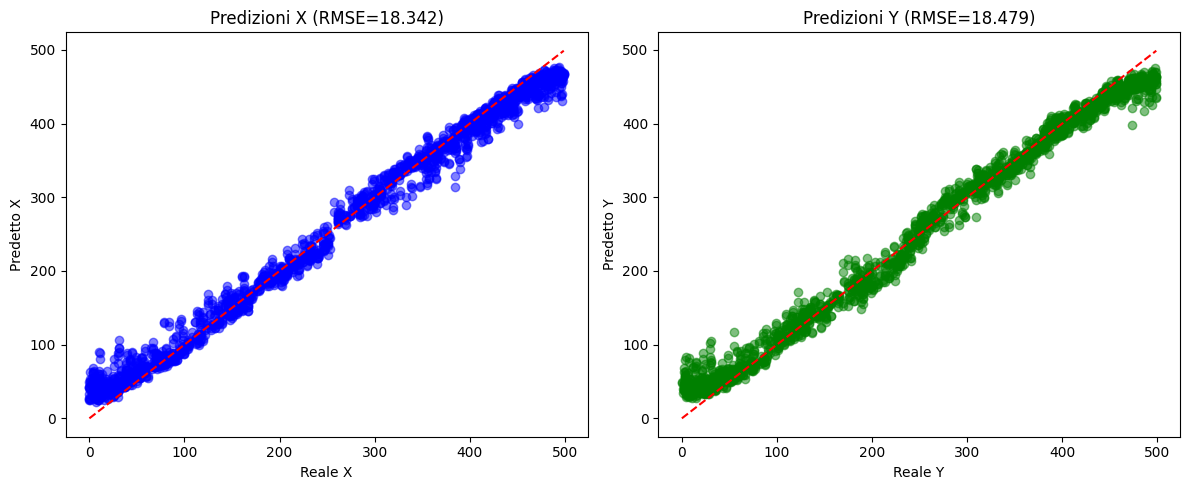

In [11]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(all_y_test_x, all_y_pred_x, color="blue", alpha=0.5)
plt.plot([min(all_y_test_x), max(all_y_test_x)], [min(all_y_test_x), max(all_y_test_x)], "r--")
plt.xlabel("Reale X")
plt.ylabel("Predetto X")
plt.title(f"Predizioni X (RMSE={np.mean(rmse_x_scores):.3f})")

plt.subplot(1, 2, 2)
plt.scatter(all_y_test_y, all_y_pred_y, color="green", alpha=0.5)
plt.plot([min(all_y_test_y), max(all_y_test_y)], [min(all_y_test_y), max(all_y_test_y)], "r--")
plt.xlabel("Reale Y")
plt.ylabel("Predetto Y")
plt.title(f"Predizioni Y (RMSE={np.mean(rmse_y_scores):.3f})")

plt.tight_layout()
plt.show()

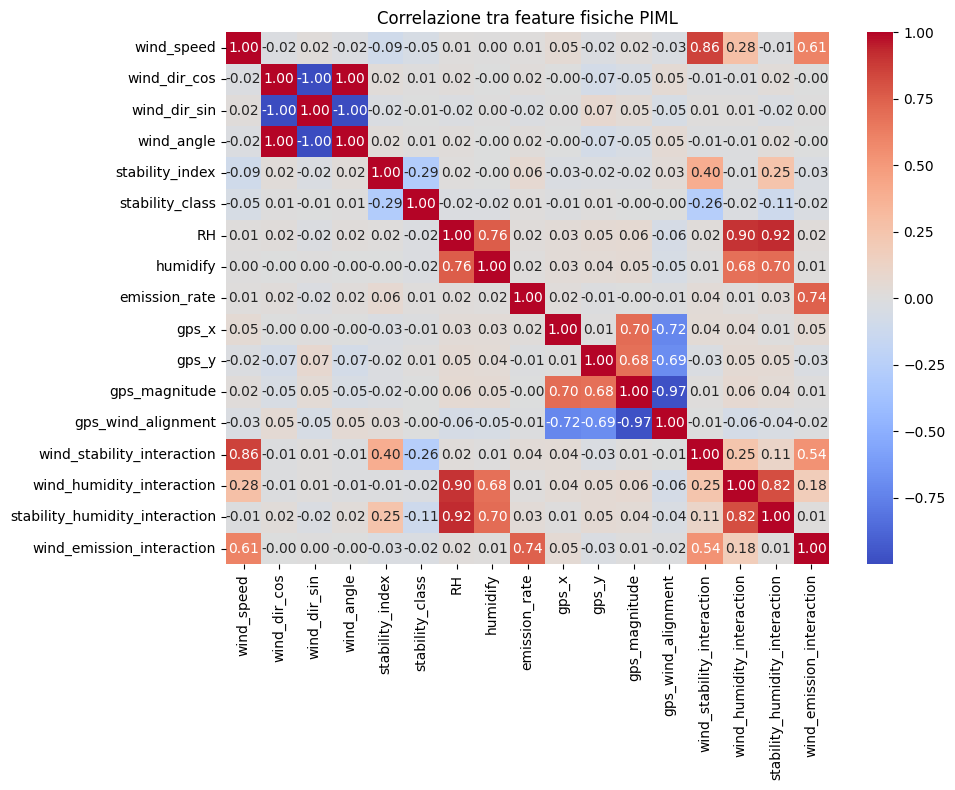

In [12]:
# Heatmap di correlazione
plt.figure(figsize=(10, 8))
sns.heatmap(pd.DataFrame(X, columns=feature_cols).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlazione tra feature fisiche PIML")
plt.tight_layout()
plt.show()

# 9. SPATIAL COMPARISON: REALE VS PREDETTO

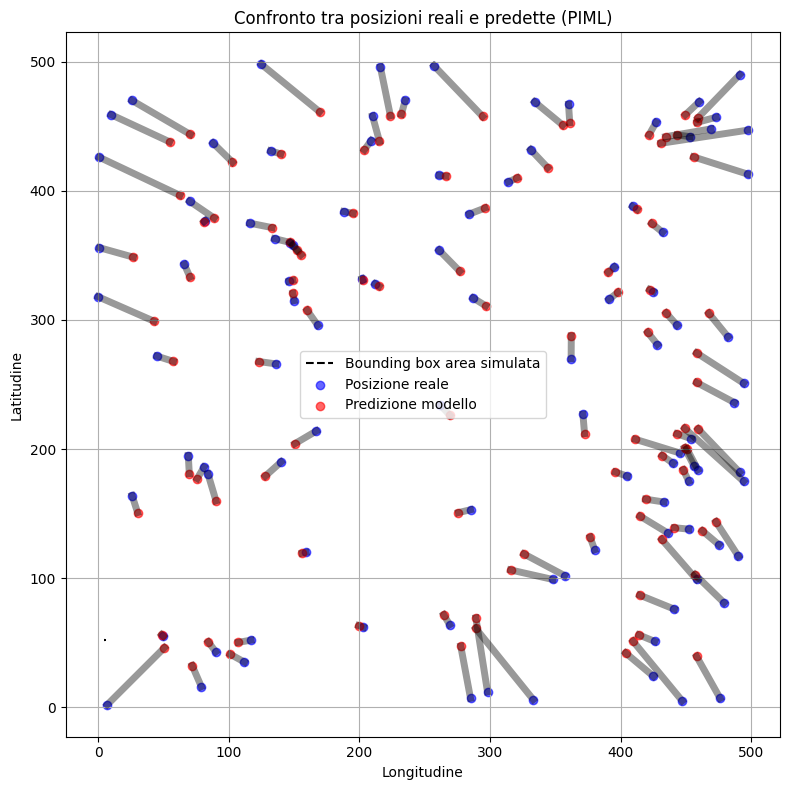

In [13]:

import matplotlib.pyplot as plt
import numpy as np

# Bounding box del quartiere
quartiere_bbox = (4.822998,52.322750,4.993973,52.431316)

# Coordinate reali e predette
x_real = np.array(all_y_test_x[:100])
y_real = np.array(all_y_test_y[:100])
x_pred = np.array(all_y_pred_x[:100])
y_pred = np.array(all_y_pred_y[:100])

plt.figure(figsize=(8,8))

# Traccia il bounding box dell’area
plt.plot(
    [quartiere_bbox[0], quartiere_bbox[2], quartiere_bbox[2], quartiere_bbox[0], quartiere_bbox[0]],
    [quartiere_bbox[1], quartiere_bbox[1], quartiere_bbox[3], quartiere_bbox[3], quartiere_bbox[1]],
    'k--', label='Bounding box area simulata'
)

# Punti reali
plt.scatter(x_real, y_real, color='blue', alpha=0.6, label='Posizione reale')

# Punti predetti
plt.scatter(x_pred, y_pred, color='red', alpha=0.6, label='Predizione modello')

# Linee che collegano reale e predetto (errore visivo)
for xr, yr, xp, yp in zip(x_real, y_real, x_pred, y_pred):
    plt.plot([xr, xp], [yr, yp], 'black', alpha=0.4, linewidth=5)

plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.title("Confronto tra posizioni reali e predette (PIML)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# A) Errori spaziali (euclidei) e metriche operative


== Errori spaziali (unità delle coordinate) ==
Mediana: 16.530530649348144
Media: 20.853734823854307
75° percentile: 28.64684946464812
95° percentile: 51.25946824770605
Predizioni entro 2.0: 2.1%
Predizioni entro 5.0: 9.3%
Predizioni entro 10.0: 28.0%


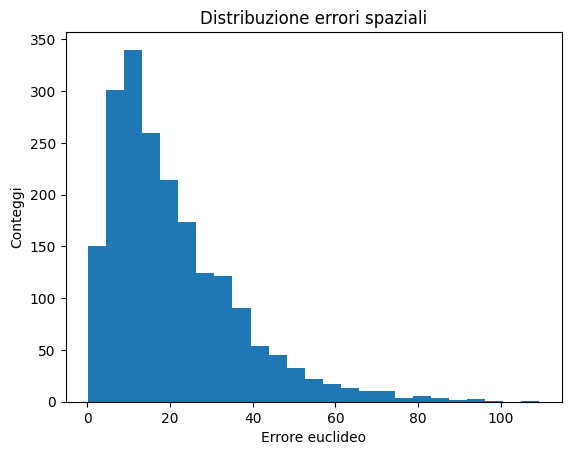

In [14]:
y_test_x = np.array(all_y_test_x)
y_test_y = np.array(all_y_test_y)
y_pred_x = np.array(all_y_pred_x)
y_pred_y = np.array(all_y_pred_y)

errors = np.sqrt((y_test_x - y_pred_x)**2 + (y_test_y - y_pred_y)**2)

print("\n== Errori spaziali (unità delle coordinate) ==")
print("Mediana:", np.median(errors))
print("Media:", np.mean(errors))
print("75° percentile:", np.percentile(errors, 75))
print("95° percentile:", np.percentile(errors, 95))

for thr in [2.0, 5.0, 10.0]:
    pct = 100 * np.mean(errors <= thr)
    print(f"Predizioni entro {thr}: {pct:.1f}%")

plt.figure()
plt.hist(errors, bins=25)
plt.xlabel("Errore euclideo")
plt.ylabel("Conteggi")
plt.title("Distribuzione errori spaziali")
plt.show()


# B) Ablation: rimuovo gps_x/gps_y e rieseguo K-Fold rapido

In [15]:
feature_cols_no_gps = [c for c in feature_cols if c not in ("gps_x","gps_y")]
X_no_gps = dataset[feature_cols_no_gps].values
scaler_no_gps = StandardScaler().fit(X_no_gps)
X_no_gps_scaled = scaler_no_gps.transform(X_no_gps)

model_no_gps = MultiOutputRegressor(ExtraTreesRegressor(n_estimators=300, random_state=42))
kf = RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)

rmse_euc = []
for train_idx, test_idx in kf.split(X_no_gps_scaled, Y):
    model_no_gps.fit(X_no_gps_scaled[train_idx], Y.iloc[train_idx])
    yp = model_no_gps.predict(X_no_gps_scaled[test_idx])
    err = np.sqrt((Y.iloc[test_idx]['source_x'].values - yp[:,0])**2 +
                  (Y.iloc[test_idx]['source_y'].values - yp[:,1])**2)
    rmse_euc.append(np.sqrt(np.mean(err**2)))

print("\n== Ablation senza GPS ==")
print(f"RMSE euclideo medio: {np.mean(rmse_euc):.3f} ± {np.std(rmse_euc):.3f}")



== Ablation senza GPS ==
RMSE euclideo medio: 162.976 ± 8.796


# C) Stima di incertezza dalle foreste (std tra alberi)

In [16]:
# Fit finale sul dataset completo, così hai uno score per ogni campione
model.fit(X_scaled, Y)

est_x = model.estimators_[0]  # ExtraTrees per X
est_y = model.estimators_[1]  # ExtraTrees per Y

# Predizione per ogni albero
tree_preds_x = np.stack([t.predict(X_scaled) for t in est_x.estimators_], axis=1)  # (n_samples, n_trees)
tree_preds_y = np.stack([t.predict(X_scaled) for t in est_y.estimators_], axis=1)

pred_std_dist = np.sqrt(tree_preds_x.std(axis=1)**2 + tree_preds_y.std(axis=1)**2)
print("\n== Incertezza predittiva (proxy) ==")
print("Mediana std distanza:", np.median(pred_std_dist))
print("95° percentile std distanza:", np.percentile(pred_std_dist, 95))

# Esempio di regola operativa: segnala solo se std<tau
tau = np.percentile(pred_std_dist, 75)  # ad es. quartile 75
conf_mask = pred_std_dist < tau
print(f"Quota di predizioni considerate 'alta confidenza' (std < Q75): {conf_mask.mean()*100:.1f}%")



== Incertezza predittiva (proxy) ==
Mediana std distanza: 45.058935610837025
95° percentile std distanza: 69.35211349949674
Quota di predizioni considerate 'alta confidenza' (std < Q75): 75.0%


In [17]:
import os
import json

# valori di esempio – sostituisci con quelli che hai nel notebook
rmse_m = 42.3   # RMSE in metri
mae_m = 31.7    # MAE in metri

BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))
VALIDATION_DIR = os.path.join(BASE_DIR, "validation")
EMISSION_DIR = os.path.join(VALIDATION_DIR, "Emission")
os.makedirs(EMISSION_DIR, exist_ok=True)

metrics = {
    "rmse_m": rmse_m,
    "mae_m": mae_m
}

out_path = os.path.join(EMISSION_DIR, "emission_piml_metrics.json")
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print("Saved:", out_path)


Saved: c:\Users\marco\Desktop\Marco\Universita\Magistrale\Traineeship\Progetto\Pention-System\validation\Emission\emission_piml_metrics.json
